# CA3 → CA1 somatic EPSC: Control, AD, Control+ER-blocked, AD+ER-blocked

Replays MCell single-bouton release trains (20 pulses, 20 Hz) through the Poirazi CA1 model and
measures what a whole-cell somatic recording would see.

Run `fig8_poirazi_synapse_validation.ipynb` first — it calibrates the synapse against published CA3→CA1
measurements. Both notebooks import the same `epsc_worker.DEFAULT_CFG`, so they cannot drift.

### What the postsynaptic model contributes

Total vesicles per trial are near-identical across conditions — the entire effect lives in the
**temporal distribution** of release. The CA1 model is not adding amplitude information; it
converts "vesicles per pulse" into "what an electrophysiologist measures", including EPSC
summation, dendritic filtering, and the driving-force sublinearity of coincident vesicles.

### How to run

**One condition at a time.** Set `CONDITION`, run the cell, wait, change it, run again.
`N_WORKERS = 1`; the cap is `epsc_worker.MAX_WORKERS = 30` (a sustained 60-worker sweep took
this machine's PSU down). Progress is checkpointed every `BATCH` trials via write-then-rename,
so a power cut costs minutes and re-running resumes.

Equivalently, headless:

```
python run_epsc.py --condition ADB --bouton V80_reltimes --trials 1000 --workers 1 --batch 10
```

### Reading the numbers

* **Absolute per-pulse amplitude** is reported alongside the pulse-1-normalised version.
  Pulse-1 release probability is low, so the normalised ratio has a small, noisy denominator.
  Do not report the normalised curve alone.
* **Amplitude vs potency.** Amplitude averages over all trials including failures (the
  experimental "mean EPSC"); potency averages only successes.
* **A failure is a pulse at which the bouton released no vesicle** — every vesicle produces an
  EPSC, but an action potential does not always produce a vesicle.

In [1]:
# =============================================================================
# Imports and configuration
# =============================================================================
import sys, time, multiprocessing as mp
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PSM = Path("/data/hdrive/phd/AD-presynaptic-calcium-model/postsynaptic_model")
if str(PSM) not in sys.path:
    sys.path.insert(0, str(PSM))

import epsc_worker as W
from plot_config import (apply_style, strip_spines, label_panel, get_condition,
                         PALETTE, DPI, save_figure)
apply_style()

CFG = dict(W.DEFAULT_CFG)          # edit in epsc_worker.py, not here

BOUTON    = "V80_reltimes"
N_TRIALS  = 1000
N_WORKERS = 15                      # cap is W.MAX_WORKERS = 30
BATCH     = 50

CONDITIONS = ["Control", "AD", "CB", "ADB"]
DT, ISI, NP, PRE = CFG["dt"], CFG["isi"], CFG["n_pulses"], CFG["pre_pad"]
DTD = DT * CFG["trace_decimate"]   # sample interval of the stored traces
OUT_DIR = W.OUT_DIR; OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGDIR = Path("/data/hdrive/phd/AD-presynaptic-calcium-model/figures/outputs"); FIGDIR.mkdir(exist_ok=True)
pulses  = np.arange(1, NP + 1)

print(f"synapse   : apical_dendrite[{CFG['syn_sec_index']}], {CFG['g_unitary_pS']:.0f} pS, "
      f"tau {CFG['tau_rise']}/{CFG['tau_decay']} ms")
print(f"electrode : soma[{CFG['soma_sec']}], Vhold {CFG['v_hold']} mV, "
      f"Rs {CFG['series_r']} MOhm")
print(f"trial     : {CFG['tstop']:.0f} ms   bouton {BOUTON}   n = {N_TRIALS}")
for c in CONDITIONS:
    print(f"  {c:8s} -> {get_condition(W.PLOT_KEY[c]).label}")

synapse   : apical_dendrite[9], 383 pS, tau 0.2/4.4 ms
electrode : soma[1], Vhold -70.0 mV, Rs 10.0 MOhm
trial     : 1350 ms   bouton V80_reltimes   n = 1000
  Control  -> Control
  AD       -> AD
  CB       -> Control + ER blocked
  ADB      -> AD + ER blocked


In [2]:
# =============================================================================
# Run ONE condition, resumably. Set CONDITION and run this cell.
# =============================================================================
CONDITION = "AD"          # "Control" | "AD" | "CB" | "ADB"

_r = W.run_condition(CONDITION, bouton=BOUTON, n_trials=N_TRIALS,
                     n_workers=N_WORKERS, batch=BATCH, out_dir=OUT_DIR, cfg=CFG)
_m = _r["A"].mean(axis=0)
print(f"\n{CONDITION}: n={len(_r['A'])}, vesicles/trial={_r['V'].sum(1).mean():.2f}, "
      f"pulse-1 EPSC={_m[0]:.2f} pA, peak={_m.max():.2f} pA at pulse {int(_m.argmax())+1}")

AD: already complete (1000 trials)



AD: n=1000, vesicles/trial=11.43, pulse-1 EPSC=2.32 pA, peak=7.70 pA at pulse 2


In [ ]:
# =============================================================================
# Load finished conditions, and check they share one postsynaptic model
# =============================================================================
res, missing = {}, []
for c in CONDITIONS:
    A, V, T = W.load_partial(c, BOUTON, OUT_DIR)
    if len(A) == 0:
        missing.append(c); continue
    res[c] = dict(A=np.array(A), V=np.array(V), T=np.array(T))

# Consistency check. The unitary EPSC is a property of the synapse, so it must be
# identical across conditions. If it is not, the conditions were simulated with
# different parameters and cannot be compared.
print(f"{'condition':10}{'n':>7}{'vesicles/trial':>16}{'unitary EPSC (pA)':>20}")
print("-" * 53)
unit = {}
for c, d in res.items():
    A, V = d["A"], d["V"]
    iso = [A[i, k] for i in range(len(V)) for k in range(1, NP - 1)
           if V[i, k] == 1 and V[i, k - 1] == 0 and V[i, k + 1] == 0]
    unit[c] = float(np.mean(iso))
    print(f"{c:10}{len(A):>7}{V.sum(1).mean():>16.2f}{unit[c]:>20.3f}")

if missing:
    print(f"\nnot yet run: {missing}")
if len(unit) > 1:
    spread = (max(unit.values()) - min(unit.values())) / np.mean(list(unit.values()))
    if spread > 0.01:
        print(f"\n*** WARNING: unitary EPSC differs by {spread*100:.1f} % across conditions.")
        print("*** They were NOT simulated with the same postsynaptic model and are not")
        print("*** directly comparable. Re-run the odd ones out before interpreting.")
    else:
        print(f"\nunitary EPSC consistent to {spread*100:.2f} % -- conditions are comparable")
assert res, "no conditions have been run yet"

condition       n  vesicles/trial   unitary EPSC (pA)
-----------------------------------------------------
Control      1000           11.11               7.956
AD           1000           11.43               7.955
CB           1000           11.03               7.944
ADB          1000           11.10               7.975

unitary EPSC consistent to 0.39 % -- conditions are comparable


In [4]:
# =============================================================================
# Derived measures
# =============================================================================
def summarise(d):
    A, V = d["A"], d["V"]
    ok = V > 0                                        # a vesicle was released
    out = {}
    out["amp"]     = A.mean(axis=0)                   # incl. failures
    out["amp_sem"] = A.std(axis=0) / np.sqrt(len(A))
    with np.errstate(invalid="ignore"):
        pot = np.where(ok, A, np.nan)
        out["potency"]     = np.nanmean(pot, axis=0)  # successes only
        out["potency_sem"] = np.nanstd(pot, axis=0) / np.sqrt(np.maximum(ok.sum(0), 1))
    out["failure"] = 1.0 - ok.mean(axis=0)
    out["ves"]     = V.mean(axis=0)
    out["ves_sem"] = V.std(axis=0) / np.sqrt(len(V))
    out["charge"]  = np.cumsum(out["amp"])
    return out

S = {c: summarise(d) for c, d in res.items()}

print(f"{'condition':10}{'p1 EPSC':>10}{'peak EPSC':>11}{'at pulse':>10}"
      f"{'peak/p1':>10}{'PPR':>8}{'p1 failure':>12}")
print("-" * 71)
for c, s in S.items():
    m = s["amp"]
    print(f"{c:10}{m[0]:>10.2f}{m.max():>11.2f}{int(m.argmax())+1:>10}"
          f"{m.max()/m[0]:>10.2f}{m[1]/m[0]:>8.2f}{s['failure'][0]:>12.2f}")

condition    p1 EPSC  peak EPSC  at pulse   peak/p1     PPR  p1 failure
-----------------------------------------------------------------------
Control         0.99       5.47         8      5.50    2.15        0.88
AD              2.32       7.70         2      3.32    3.32        0.75
CB              2.43       5.37         7      2.21    1.39        0.72
ADB             2.26       5.49         8      2.43    1.56        0.74


/tmp/ipykernel_353971/1449850593.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(h_pad=0.8, w_pad=0.7, rect=[0, 0, 1, 0.96])


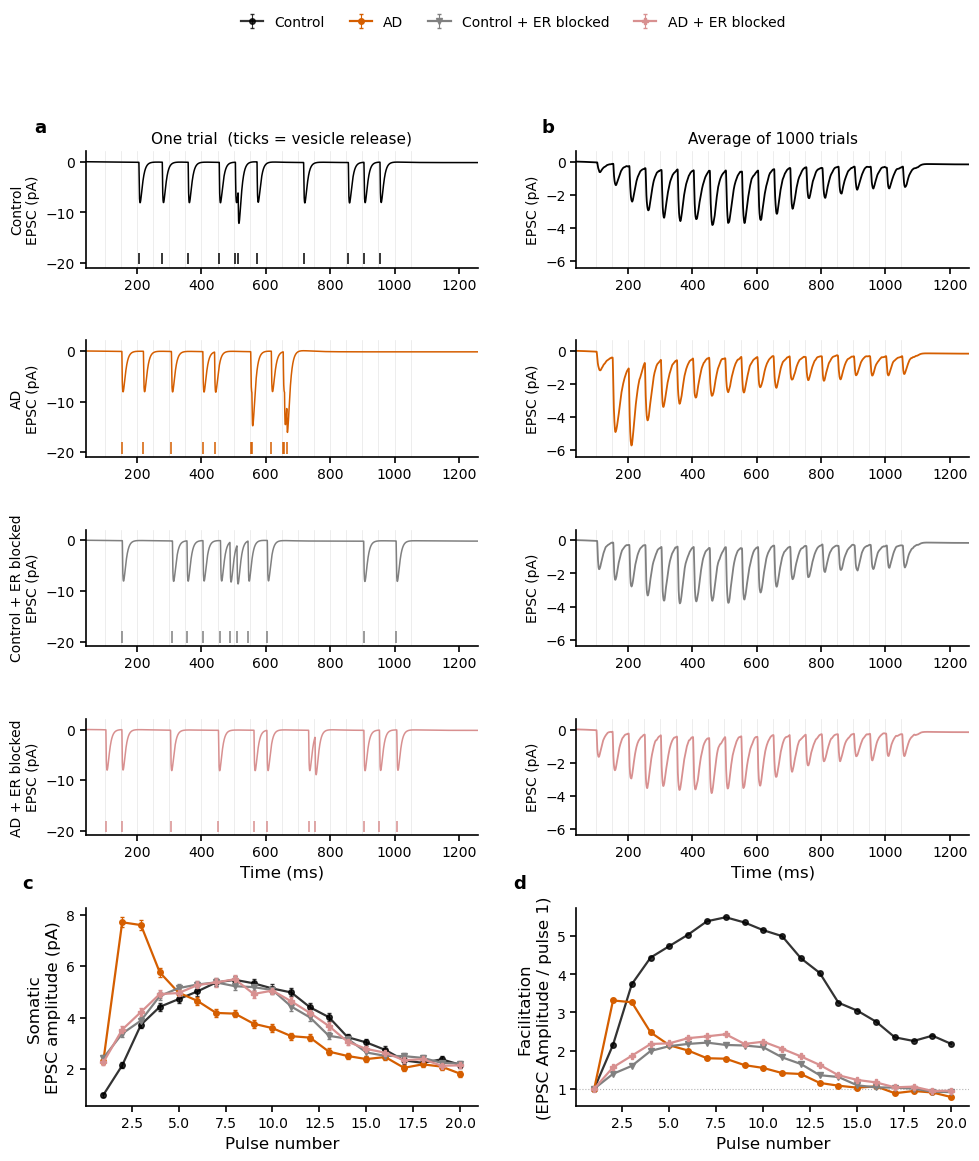

single trials are sparse and all-or-none; the average is smooth because across
trials some release occurred on every pulse. No single trial looks like the mean.


In [ ]:
# =============================================================================
# FIGURE 1 -- one example trial and the grand average, per condition, with a
#             per-pulse summary (amplitude, facilitation) beneath
#             -> figures/epsc_trials_and_average.png / .pdf
# =============================================================================
order = [c for c in CONDITIONS if c in res]
t_ds  = np.arange(next(iter(res.values()))["T"].shape[1]) * DTD
base_ix = slice(0, int((PRE - 10) / DTD))

# pick, per condition, the trial whose vesicle count is closest to the median
example = {}
for c in order:
    tot = res[c]["V"].sum(1)
    example[c] = int(np.argmin(np.abs(tot - np.median(tot))))

# One y-scale per column, so conditions are directly comparable by eye.
trial_tr, avg_tr = {}, {}
for c in order:
    d, i = res[c], example[c]
    trial_tr[c] = d["T"][i] - np.median(d["T"][i][base_ix])
    m = d["T"].mean(axis=0); avg_tr[c] = m - np.median(m[base_ix])
ymin_trial = min(v.min() for v in trial_tr.values()) * 1.30
ymin_avg   = min(v.min() for v in avg_tr.values()) * 1.12
tick_lo, tick_hi = ymin_trial * 0.97, ymin_trial * 0.86

n_top = len(order)
fig = plt.figure(figsize=(11.4, 2.05 * n_top + 4.2))
gs = fig.add_gridspec(n_top + 1, 2, height_ratios=[1] * n_top + [1.7],
                      hspace=0.55, wspace=0.25)

axes = np.empty((n_top, 2), dtype=object)
for r in range(n_top):
    for k in range(2):
        axes[r, k] = fig.add_subplot(
            gs[r, k],
            sharex=axes[0, 0] if (r, k) != (0, 0) else None,   # all share time axis
            sharey=axes[0, k] if r != 0 else None)             # y shared per column

for r, c in enumerate(order):
    cond = get_condition(W.PLOT_KEY[c])
    rel = W.load_release_times(W.list_trial_files(c, BOUTON)[example[c]],
                               CFG["release_unit"]) + PRE

    p = axes[r][0]                                    # one example trial
    p.plot(t_ds, trial_tr[c], color=cond.color, lw=1.1)
    p.vlines(rel, tick_lo, tick_hi, color=cond.color, lw=1.1)
    p.set_ylabel(f"{cond.label}\nEPSC (pA)", fontsize=10)
    if r == 0:
        p.set_title("One trial  (ticks = vesicle release)", fontsize=11)

    p = axes[r][1]                                    # grand average
    p.plot(t_ds, avg_tr[c], color=cond.color, lw=1.3)
    p.set_ylabel("EPSC (pA)", fontsize=10)
    if r == 0:
        p.set_title(f"Average of {len(res[c]['T'])} trials", fontsize=11)

axes[0][0].set_ylim(ymin_trial, max(2.0, -ymin_trial * 0.10))
axes[0][1].set_ylim(ymin_avg, max(0.5, -ymin_avg * 0.10))

for r in range(n_top):
    for k in range(2):
        q = axes[r][k]
        for j in range(NP):
            q.axvline(PRE + j * ISI, color="0.90", lw=0.5, zorder=0)
        strip_spines(q)
axes[0][0].set_xlim(PRE - 60, PRE + NP * ISI + 160)
for k in range(2):
    axes[-1][k].set_xlabel("Time (ms)")
label_panel(axes[0][0], "a", x=-0.13, y=1.16)
label_panel(axes[0][1], "b", x=-0.09, y=1.16)

# -- bottom row: per-pulse summary, all conditions overlaid ------------------
axc = fig.add_subplot(gs[n_top, 0])
axd = fig.add_subplot(gs[n_top, 1])
main = [("amp", "amp_sem", "Somatic \nEPSC amplitude (pA)"),
        (None,  None,      "Facilitation \n(EPSC Amplitude / pulse 1)")]
for q, (key, semkey, ylab) in zip((axc, axd), main):
    for c in order:
        cond, s = get_condition(W.PLOT_KEY[c]), S[c]
        y = s["amp"] / s["amp"][0] if key is None else s[key]
        q.errorbar(pulses, y, yerr=(s[semkey] if semkey else None), color=cond.color,
                   marker=cond.marker, ms=4, lw=1.6, alpha=cond.alpha, zorder=cond.zorder,
                   label=cond.label, capsize=1.6, elinewidth=0.8)
    if key is None:
        q.axhline(1.0, color="0.7", lw=0.8, ls=":")
    q.set_xlabel("Pulse number"); q.set_ylabel(ylab)
    # q.set_title(title, fontsize=11)
    strip_spines(q)
label_panel(axc, "c", x=-0.16, y=1.10)
label_panel(axd, "d", x=-0.16, y=1.10)

# One shared legend above all panels instead of one inside axc.
handles, labels = axc.get_legend_handles_labels()
fig.tight_layout(h_pad=0.8, w_pad=0.7, rect=[0, 0, 1, 0.96])
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          ncol=len(labels), frameon=False, fontsize=10, handlelength=1.6,
          columnspacing=1.8)
save_figure(fig, str(FIGDIR / "fig9_postsynaptic_train_EPSC.png"), dpi=DPI)
save_figure(fig, str(FIGDIR / "fig9_postsynaptic_train_EPSC.pdf"), dpi=DPI)
plt.show()
print("single trials are sparse and all-or-none; the average is smooth because across")
print("trials some release occurred on every pulse. No single trial looks like the mean.")